In [3]:
import pandas as pd

news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news["date"] = pd.to_datetime(news["date"], errors="coerce", utc=True)

news = news.dropna(subset=["date"])

news["date"] = news["date"].dt.tz_convert(None)

news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A


In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

news["sentiment"] = news["headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

news.head()

,Unnamed: 0,headline,url,publisher,date,stock,sentiment
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,0.000
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,0.000
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,0.000
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,0.000
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,0.296


In [5]:
news["date_only"] = news["date"].dt.date

In [6]:
stocks["date_only"] = stocks["Date"].dt.date

NameError: name 'stocks' is not defined

In [7]:
import pandas as pd

AAPL = pd.read_csv("../data/raw/AAPL.csv")
AMZN = pd.read_csv("../data/raw/AMZN.csv")
GOOG = pd.read_csv("../data/raw/GOOG.csv")
META = pd.read_csv("../data/raw/META.csv")
NVDA = pd.read_csv("../data/raw/NVDA.csv")

In [8]:
AAPL["stock"] = "AAPL"
AMZN["stock"] = "AMZN"
GOOG["stock"] = "GOOG"
META["stock"] = "META"
NVDA["stock"] = "NVDA"

In [9]:
stocks = pd.concat([AAPL, AMZN, GOOG, META, NVDA])

In [10]:
stocks["date_only"] = stocks["Date"].dt.date

AttributeError: Can only use .dt accessor with datetimelike values

In [11]:
stocks["Date"] = pd.to_datetime(stocks["Date"])

In [13]:
stocks["date_only"] = stocks["Date"].dt.date

In [14]:
stocks.head()

,Date,Close,High,Low,Open,Volume,stock,date_only
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,2009-01-02
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,2009-01-05
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,2009-01-06
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,2009-01-07
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,2009-01-08


In [15]:
daily_sentiment = news.groupby(
    ["stock","date_only"]
)["sentiment"].mean().reset_index()

In [16]:
merged = pd.merge(
    daily_sentiment,
    stocks,
    on=["stock","date_only"],
    how="inner"
)

In [17]:
merged.head()

,stock,date_only,sentiment,Date,Close,High,Low,Open,Volume
0,AAPL,2020-06-09,0.246900,2020-06-09,83.419868,83.812728,80.514643,80.546170,147712400
1,AAPL,2020-06-10,0.198850,2020-06-10,85.566071,86.034107,83.929150,84.368087,166651600
2,AMZN,2020-06-09,0.077775,2020-06-09,130.042999,131.321503,126.250000,126.472000,103520000
3,AMZN,2020-06-10,0.391233,2020-06-10,132.372498,136.117493,131.313004,132.250000,98920000
4,GOOG,2020-06-04,0.000000,2020-06-04,70.129089,71.458985,69.759124,71.033893,29686000


In [18]:
correlation = merged["sentiment"].corr(
    merged["daily_return"]
)

print(correlation)

KeyError: 'daily_return'

In [19]:
stocks["daily_return"] = stocks.groupby("ticker")["Close"].pct_change()

KeyError: 'ticker'

In [20]:
stocks.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'stock', 'date_only'], dtype='str')

In [21]:
stocks["daily_return"] = stocks.groupby("stock")["Close"].pct_change()

In [22]:
stocks.head()

,Date,Close,High,Low,Open,Volume,stock,date_only,daily_return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,2009-01-02,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,2009-01-05,0.042204
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,2009-01-06,-0.016494
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,2009-01-07,-0.021609
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,2009-01-08,0.018570


In [23]:
merged = pd.merge(
    news,
    stocks,
    on=["date_only","stock"],
    how="inner"
)

In [24]:
merged = merged.dropna(subset=["sentiment","daily_return"])

In [25]:
correlation = merged["sentiment"].corr(merged["daily_return"])

print("Correlation between sentiment and daily return:", correlation)

Correlation between sentiment and daily return: 0.04174870540499027


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

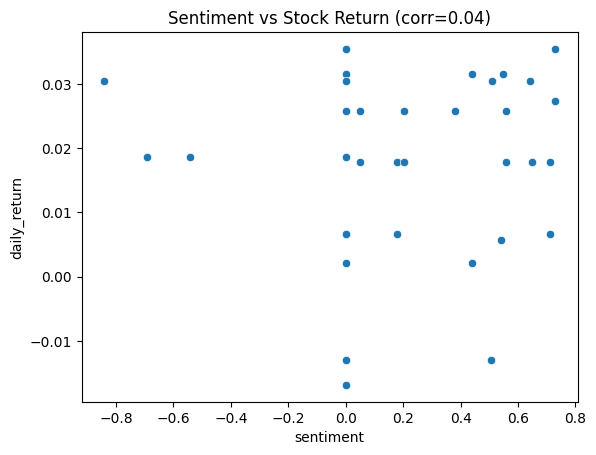

In [28]:
import seaborn as sns

sns.scatterplot(
    x=merged["sentiment"],
    y=merged["daily_return"]
)

plt.title(f"Sentiment vs Stock Return (corr={correlation:.2f})")

plt.show()

In [29]:
def classify_sentiment(score):

    if score > 0.05:
        return "positive"

    elif score < -0.05:
        return "negative"

    else:
        return "neutral"

merged["sentiment_category"] = merged["sentiment"].apply(classify_sentiment)

In [30]:
category_returns = merged.groupby(
    "sentiment_category"
)["daily_return"].mean()

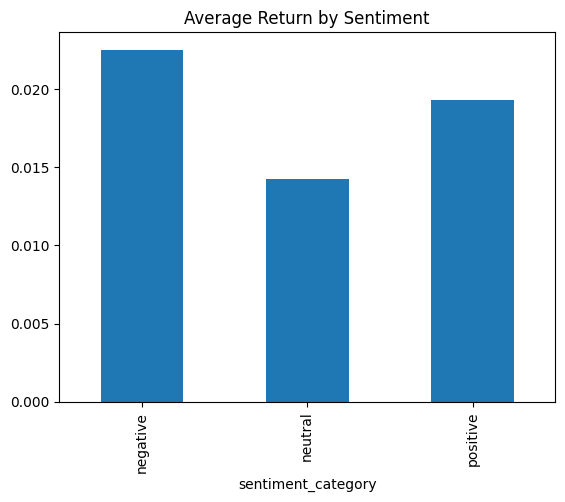

In [31]:
category_returns.plot(kind="bar")

plt.title("Average Return by Sentiment")

plt.show()